In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
data = fetch_california_housing(as_frame=True)
df = data.frame
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [3]:
df.shape

(20640, 9)

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [6]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


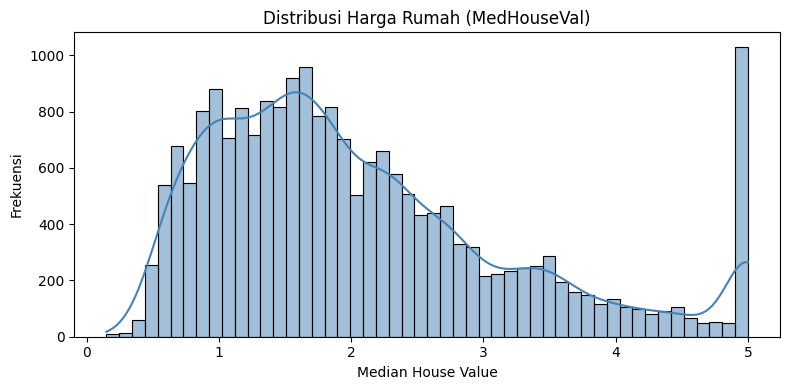

In [7]:
plt.figure(figsize=(8, 4))
sns.histplot(df['MedHouseVal'], bins=50, kde=True, color='steelblue')
plt.title('Distribusi Harga Rumah (MedHouseVal)')
plt.xlabel('Median House Value')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

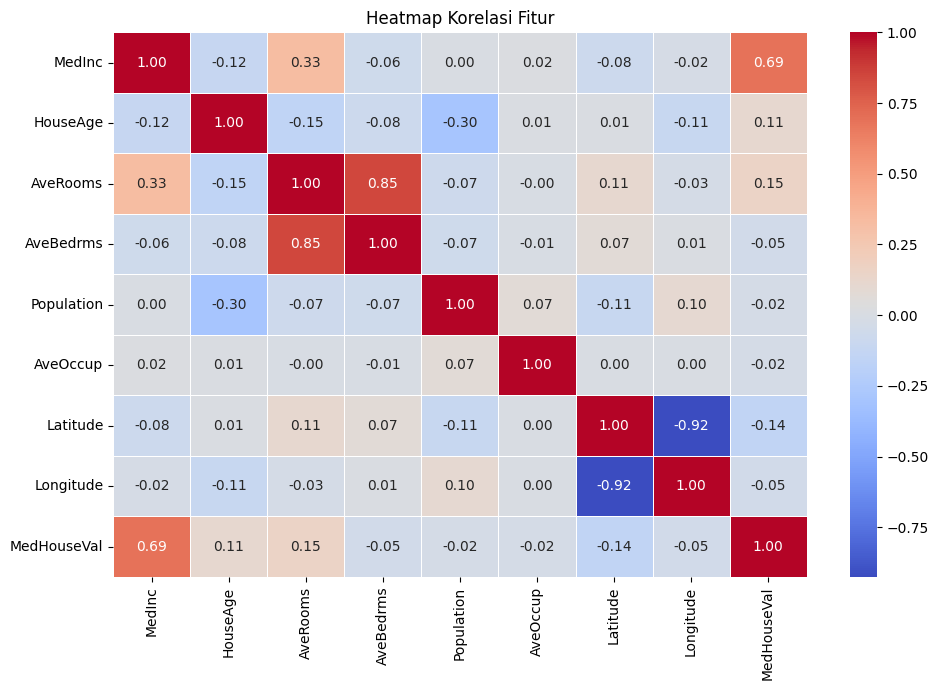

In [8]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Korelasi Fitur')
plt.tight_layout()
plt.show()

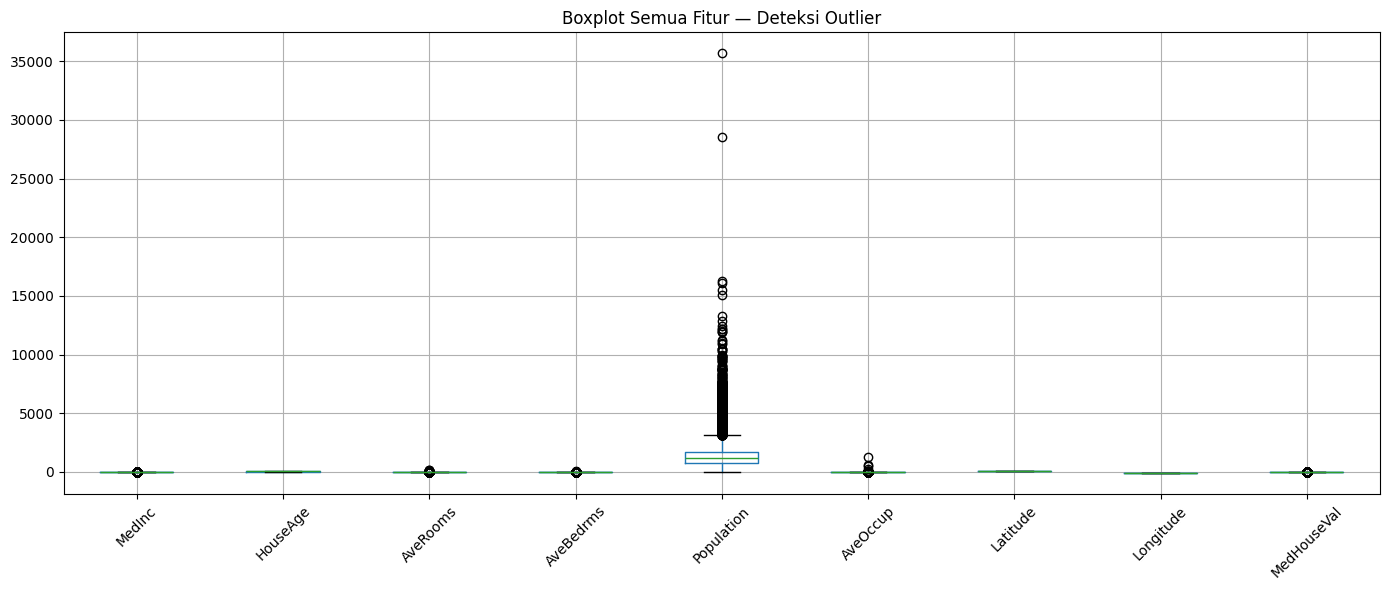

Jumlah Outlier per Kolom (Metode IQR) 
  MedInc              : 681 outlier (3.30%)
  HouseAge            : 0 outlier (0.00%)
  AveRooms            : 511 outlier (2.48%)
  AveBedrms           : 1424 outlier (6.90%)
  Population          : 1196 outlier (5.79%)
  AveOccup            : 711 outlier (3.44%)
  Latitude            : 0 outlier (0.00%)
  Longitude           : 0 outlier (0.00%)
  MedHouseVal         : 1071 outlier (5.19%)


In [9]:
plt.figure(figsize=(14, 6))
df.boxplot(rot=45)
plt.title('Boxplot Semua Fitur — Deteksi Outlier')
plt.tight_layout()
plt.show()

print("Jumlah Outlier per Kolom (Metode IQR) ")
outlier_summary = {}
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outlier = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = n_outlier
    print(f"  {col:20s}: {n_outlier} outlier ({n_outlier/len(df)*100:.2f}%)")

In [10]:
df_clipped = df.copy()
for col in df_clipped.columns:
    Q1 = df_clipped[col].quantile(0.25)
    Q3 = df_clipped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clipped[col] = df_clipped[col].clip(lower, upper)

df = df_clipped

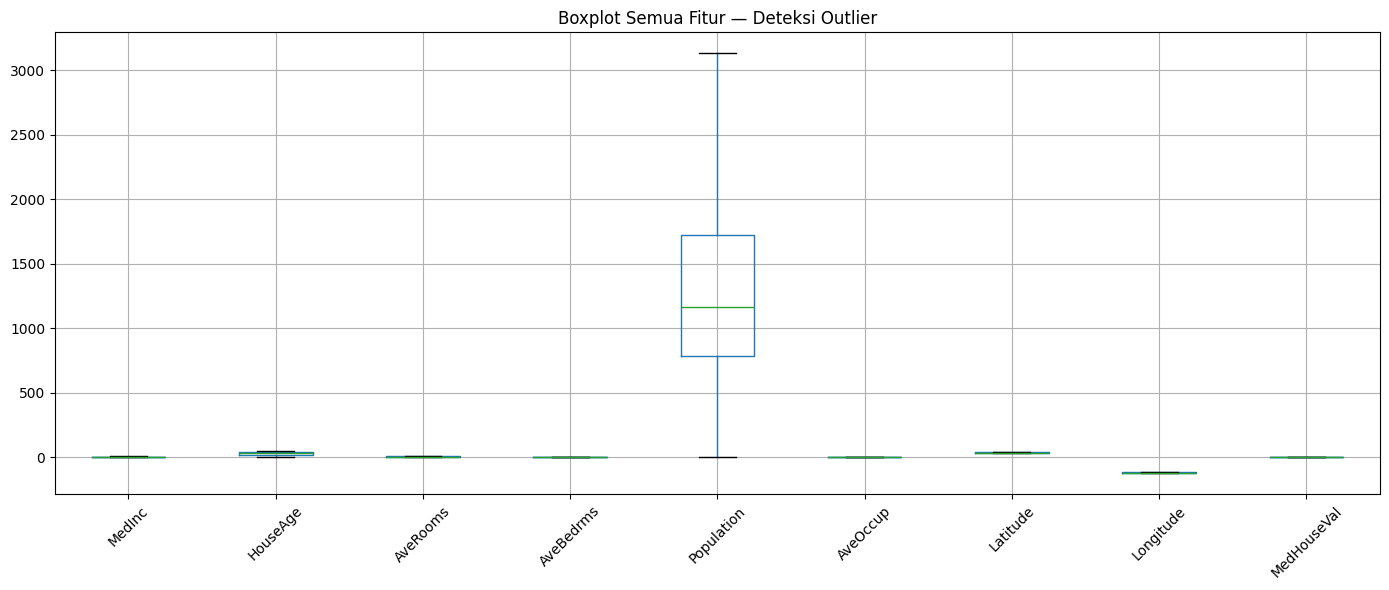

 Jumlah Outlier per Kolom (Metode IQR) 
  MedInc              : 0 outlier (0.00%)
  HouseAge            : 0 outlier (0.00%)
  AveRooms            : 0 outlier (0.00%)
  AveBedrms           : 0 outlier (0.00%)
  Population          : 0 outlier (0.00%)
  AveOccup            : 0 outlier (0.00%)
  Latitude            : 0 outlier (0.00%)
  Longitude           : 0 outlier (0.00%)
  MedHouseVal         : 0 outlier (0.00%)


In [11]:
plt.figure(figsize=(14, 6))
df.boxplot(rot=45)
plt.title('Boxplot Semua Fitur — Deteksi Outlier')
plt.tight_layout()
plt.show()

print(" Jumlah Outlier per Kolom (Metode IQR) ")
outlier_summary = {}
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outlier = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = n_outlier
    print(f"  {col:20s}: {n_outlier} outlier ({n_outlier/len(df)*100:.2f}%)")

In [12]:
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

print(f"\nUkuran data train : {X_train.shape}")
print(f"Ukuran data test  : {X_test.shape}")


Ukuran data train : (16512, 8)
Ukuran data test  : (4128, 8)


In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [15]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)
 
print(f"Intercept : {model.intercept_:.4f}")
coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': model.coef_
}).sort_values('Koefisien', ascending=False)
print(coef_df.to_string(index=False))

y_pred = model.predict(X_test_scaled)

Intercept : 2.0630
     Fitur  Koefisien
    MedInc   0.838511
  HouseAge   0.164264
 AveBedrms   0.154171
Population   0.038597
  AveRooms  -0.140304
  AveOccup  -0.261397
 Longitude  -0.751041
  Latitude  -0.820110


In [16]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
 
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
 
print(f"  MSE   : {mse:.4f}")
print(f"  RMSE  : {rmse:.4f}")
print(f"  R²    : {r2:.4f}  ({r2*100:.2f}%)")
print(f"  MAPE  : {mape:.2f}%")


  MSE   : 0.4424
  RMSE  : 0.6651
  R²    : 0.6501  (65.01%)
  MAPE  : 30.37%


In [17]:
print("\n Interpretasi ")
if r2 >= 0.9:
    interpretasi = "Sangat baik"
elif r2 >= 0.75:
    interpretasi = "Baik"
elif r2 >= 0.5:
    interpretasi = "Cukup"
else:
    interpretasi = "Perlu perbaikan"
print(f"R² Score {r2:.4f} → {interpretasi}")
print(f"Model rata-rata meleset sebesar {mape:.2f}% dari nilai aktual (MAPE)")


 Interpretasi 
R² Score 0.6501 → Cukup
Model rata-rata meleset sebesar 30.37% dari nilai aktual (MAPE)


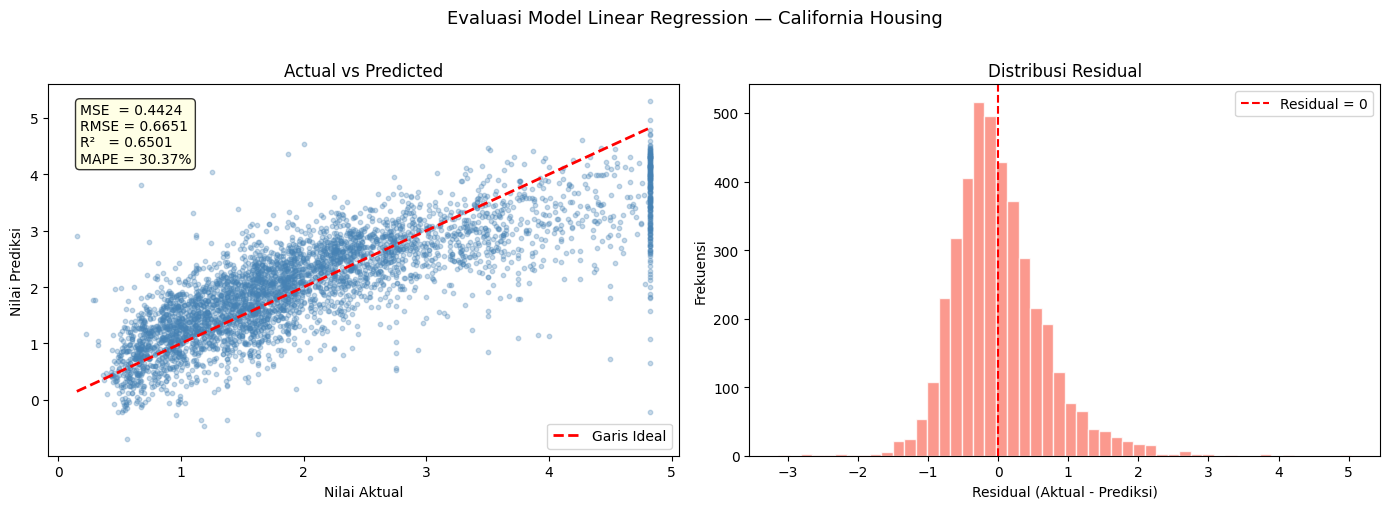

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.3, color='steelblue', s=10)
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', linewidth=2, label='Garis Ideal'
)
axes[0].set_xlabel('Nilai Aktual')
axes[0].set_ylabel('Nilai Prediksi')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()
 
# Metrik
metrik_text = f"MSE  = {mse:.4f}\nRMSE = {rmse:.4f}\nR²   = {r2:.4f}\nMAPE = {mape:.2f}%"
axes[0].text(
    0.05, 0.95, metrik_text,
    transform=axes[0].transAxes,
    fontsize=10, verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
)
 
# Plot 2: Distribusi Residual
residuals = y_test - y_pred
axes[1].hist(residuals, bins=50, color='salmon', edgecolor='white', alpha=0.8)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Residual = 0')
axes[1].set_xlabel('Residual (Aktual - Prediksi)')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Distribusi Residual')
axes[1].legend()
 
plt.suptitle('Evaluasi Model Linear Regression — California Housing', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
 


In [19]:
model = RandomForestRegressor(
    n_estimators=200,     
    max_features='sqrt',  
    max_depth=20,         
    min_samples_leaf=4,   
    random_state=42
)

model.fit(X_train_scaled, y_train)

train_score = model.score(X_train_scaled, y_train)
test_score  = model.score(X_test_scaled, y_test)
selisih     = train_score - test_score

print(f"\nR² Train : {train_score:.4f}")
print(f"R² Test  : {test_score:.4f}")
print(f"Selisih  : {selisih:.4f}")


R² Train : 0.9066
R² Test  : 0.8020
Selisih  : 0.1046


In [20]:
if selisih > 0.1:
    print("Indikasi : Overfitting")
elif train_score < 0.7 and test_score < 0.7:
    print("Indikasi : Underfitting")
else:
    print("Indikasi : Fit yang baik ")

Indikasi : Overfitting


In [21]:
param_grid = {
    'max_depth'        : [10, 15, 20],
    'min_samples_leaf' : [4, 8, 10, 15],
    'max_samples'      : [0.7, 0.8, 0.9]
}

grid_search = GridSearchCV(
    estimator  = RandomForestRegressor(
                     n_estimators=200,
                     max_features='sqrt',
                     random_state=42
                 ),
    param_grid = param_grid,
    cv         = 5,           
    scoring    = 'r2',
    n_jobs     = -1,          
    verbose    = 1
)

grid_search.fit(X_train_scaled, y_train)

print(f"Parameter terbaik : {grid_search.best_params_}")
print(f"R² terbaik (CV)   : {grid_search.best_score_:.4f}")


best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_scaled)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Parameter terbaik : {'max_depth': 20, 'max_samples': 0.9, 'min_samples_leaf': 4}
R² terbaik (CV)   : 0.8038


In [22]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Hindari pembagian dengan nol
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
 
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
 

print("HASIL EVALUASI MODEL RANDOM FOREST (TUNED)")
print("="*40)
print(f"  MSE   : {mse:.4f}")
print(f"  RMSE  : {rmse:.4f}")
print(f"  R²    : {r2:.4f}  ({r2*100:.2f}%)")
print(f"  MAPE  : {mape:.2f}%")


HASIL EVALUASI MODEL RANDOM FOREST (TUNED)
  MSE   : 0.2520
  RMSE  : 0.5020
  R²    : 0.8007  (80.07%)
  MAPE  : 20.11%


In [23]:
print("Interpretasi ")
if r2 >= 0.9:
    interpretasi = "Sangat baik"
elif r2 >= 0.75:
    interpretasi = "Baik"
elif r2 >= 0.5:
    interpretasi = "Cukup"
else:
    interpretasi = "Perlu perbaikan"
print(f"R² Score {r2:.4f} → {interpretasi}")
print(f"Model rata-rata meleset sebesar {mape:.2f}% dari nilai aktual (MAPE)")

Interpretasi 
R² Score 0.8007 → Baik
Model rata-rata meleset sebesar 20.11% dari nilai aktual (MAPE)


Interpretasi
R² Score 0.8007 → Baik
Model rata-rata meleset sebesar 20.11% dari nilai aktual (MAPE)


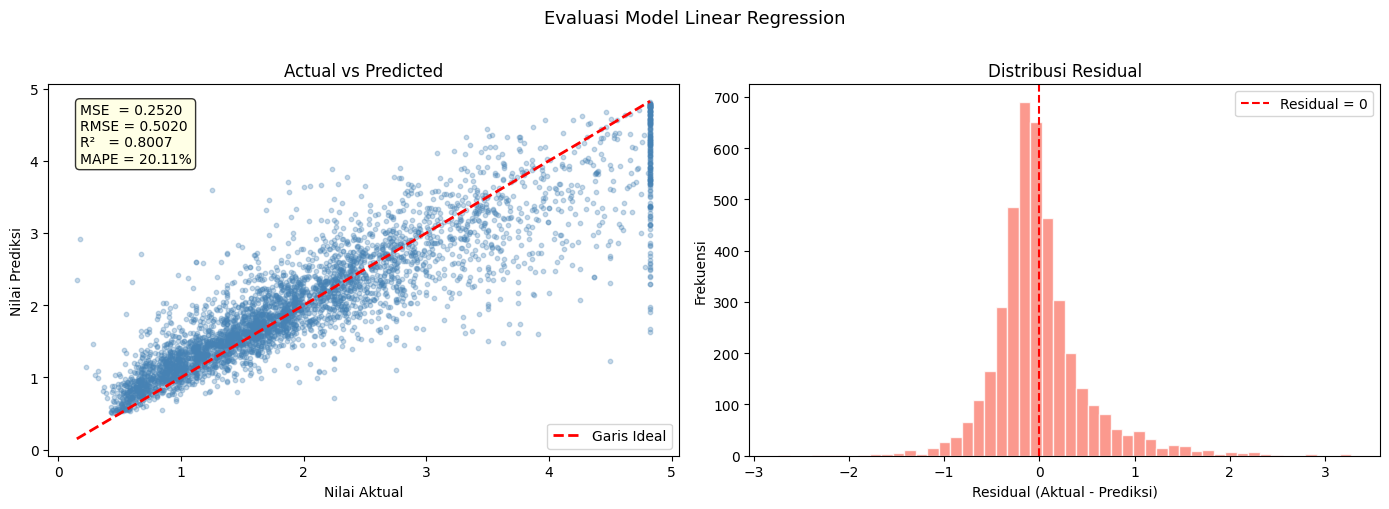

In [24]:
print("Interpretasi")
if r2 >= 0.9:
    interpretasi = "Sangat baik"
elif r2 >= 0.75:
    interpretasi = "Baik"
elif r2 >= 0.5:
    interpretasi = "Cukup"
else:
    interpretasi = "Perlu perbaikan"
print(f"R² Score {r2:.4f} → {interpretasi}")
print(f"Model rata-rata meleset sebesar {mape:.2f}% dari nilai aktual (MAPE)")
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.3, color='steelblue', s=10)
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', linewidth=2, label='Garis Ideal'
)
axes[0].set_xlabel('Nilai Aktual')
axes[0].set_ylabel('Nilai Prediksi')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()
 
# Tambahkan teks metrik
metrik_text = f"MSE  = {mse:.4f}\nRMSE = {rmse:.4f}\nR²   = {r2:.4f}\nMAPE = {mape:.2f}%"
axes[0].text(
    0.05, 0.95, metrik_text,
    transform=axes[0].transAxes,
    fontsize=10, verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
)
 
# Plot 2: Distribusi Residual
residuals = y_test - y_pred
axes[1].hist(residuals, bins=50, color='salmon', edgecolor='white', alpha=0.8)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Residual = 0')
axes[1].set_xlabel('Residual (Aktual - Prediksi)')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Distribusi Residual')
axes[1].legend()
 
plt.suptitle('Evaluasi Model Linear Regression', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
 